In [1]:
# install voxelmorph, which will also install dependencies: neurite and pystrum
!pip install voxelmorph 

  Using cached voxelmorph-0.2-py3-none-any.whl (54 kB)
  Using cached neurite-0.2-py3-none-any.whl (108 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached nibabel-5.3.2-py3-none-any.whl (3.3 MB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl (2.9 MB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached scikit_image-0.25.2-cp310-cp310-win_amd64.whl (12.8 MB)
  Using cached scikit_learn-1.7.0-cp310-cp310-win_amd64.whl (10.7 MB)
  Using cached pystrum-0.4.tar.gz (17 kB)
  Using cached matplotlib-3.10.3-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached fonttools-4.58.4-cp310-cp310-win_amd64.whl (2.2 MB)
  Using cached kiwisolver-1.4.8-cp310-cp310-win_amd64.whl (71 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pillow-11.2.1-cp310-cp310-win_amd64.whl (2.7 MB)
  Using cached pyparsing-3.

In [5]:
!pip install tensorflow==2.10.1

  Using cached tensorflow-2.10.1-cp310-cp310-win_amd64.whl (455.9 MB)
  Using cached grpcio-1.73.1-cp310-cp310-win_amd64.whl (4.3 MB)
  Using cached keras-2.10.0-py2.py3-none-any.whl (1.7 MB)
  Using cached termcolor-3.1.0-py3-none-any.whl (7.7 kB)
  Using cached tensorboard-2.10.1-py3-none-any.whl (5.9 MB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl (30 kB)
  Using cached wrapt-1.17.2-cp310-cp310-win_amd64.whl (38 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached gast-0.4.0-py3-none-any.whl (9.8 kB)
  Using cached tensorflow_estimator-2.10.0-py2.py3-none-any.whl (438 kB)
  Using cached Keras_Preprocessing-1.1.2-py2.py3-none-any.whl (42 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached absl_py-2.3.0-py3-none-any.whl (135 kB)
  Using cached protobuf-3.19.6-cp310-cp310-win_amd64.whl (895 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Us

In [3]:
!pip install numpy==1.23.5



In [6]:
# imports
import os, sys

# third party imports
import numpy as np
import tensorflow as tf
assert tf.__version__.startswith('2.'), 'This tutorial assumes Tensorflow 2.0+'

In [7]:
# local imports
import voxelmorph as vxm
import neurite as ne

In [11]:
!pip install opencv-python


  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)


In [12]:
import cv2
import os

cap = cv2.VideoCapture("C:\\Users\\orilab\\Desktop\\masumoto\\voxelMorph\\IMG_0713.mov")
output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)

i = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  # グレースケール化（2Dにする）
    resized = cv2.resize(gray, (160, 192))          # 必要ならリサイズ
    cv2.imwrite(f"{output_dir}/frame_{i:04d}.png", resized)
    i += 1

cap.release()

In [64]:
def vxm_data_generator(x_data, batch_size=32):
    """
    Generator that takes in data of size [N, H, W], and yields data for
    our custom vxm model. Note that we need to provide numpy data for each
    input, and each output.

    inputs:  moving [bs, H, W, 1], fixed image [bs, H, W, 1]
    outputs: moved image [bs, H, W, 1], zero-gradient [bs, H, W, 2]
    """

    # preliminary sizing
    vol_shape = x_data.shape[1:] # extract data shape
    ndims = len(vol_shape)
    
    # prepare a zero array the size of the deformation
    # we'll explain this below
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        # prepare inputs:
        # images need to be of the size [batch_size, H, W, 1]
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]
        inputs = [moving_images, fixed_images]
        
        # prepare outputs (the 'true' moved image):
        # of course, we don't have this, but we know we want to compare 
        # the resulting moved image with the fixed image. 
        # we also wish to penalize the deformation field. 
        outputs = [fixed_images, zero_phi]
        
        yield (inputs, outputs)

In [108]:
import os
import cv2
import numpy as np

frame_dir = 'C:\\Users\\orilab\\Desktop\\masumoto\\voxelMorph\\frames'  # ← 適切なパスに修正してください
frame_files = sorted(os.listdir(frame_dir))

images = []

for fname in frame_files:
    img_path = os.path.join(frame_dir, fname)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # グレースケールで読み込み
    if img is None:
        print(f"読み込み失敗: {fname}")
        continue
    resized = cv2.resize(img, (192, 192))  # 幅192、高さ192
    images.append(resized)

x_data = np.array(images)

# 🔀 シャッフル（ランダムなインデックスを取得）
np.random.seed(42)  # 再現性のために固定（任意）
indices = np.random.permutation(len(x_data))
x_data = x_data[indices]

# データ分割
x_train = x_data[:-2000]
x_val = x_data[-2000:-1000]
x_test = x_data[-1000:]

# 正規化
x_train = x_train.astype('float32') / 255
x_val = x_val.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# 確認
print("x_train.shape:", x_train.shape)
print("x_val.shape:", x_val.shape)
print("x_test.shape:", x_test.shape)


x_train.shape: (6447, 192, 192)
x_val.shape: (1000, 192, 192)
x_test.shape: (1000, 192, 192)


In [109]:
nb_val = 1000
nb_test = 1000

# x_data.shape は (枚数, 高さ, 幅) と仮定
x_test = x_data[-nb_test:, ...]                 # 最後の1000枚
x_val = x_data[-(nb_test + nb_val):-nb_test, ...]  # その前の1000枚
x_train = x_data[:-(nb_test + nb_val), ...]     # 残りすべて

print("訓練データ数:", x_train.shape[0])
print("検証データ数:", x_val.shape[0])
print("テストデータ数:", x_test.shape[0])



訓練データ数: 6447
検証データ数: 1000
テストデータ数: 1000


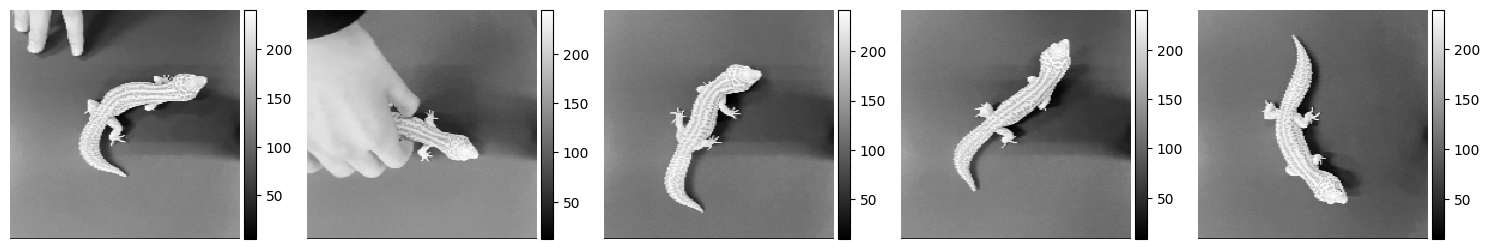

In [110]:
nb_vis = 5

# choose nb_vis sample indexes
idx = np.random.choice(x_train.shape[0], nb_vis, replace=False)
example_digits = [f for f in x_train[idx, ...]]

# plot
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True);

In [111]:
# fix data
x_train = x_train.astype('float')/255
x_val = x_val.astype('float')/255
x_test = x_test.astype('float')/255

# verify
print('training maximum value', x_train.max())
print(gray.shape)
print('shape of training data', x_train.shape)

training maximum value 0.9725490196078431
(1078, 1030)
shape of training data (6447, 192, 192)


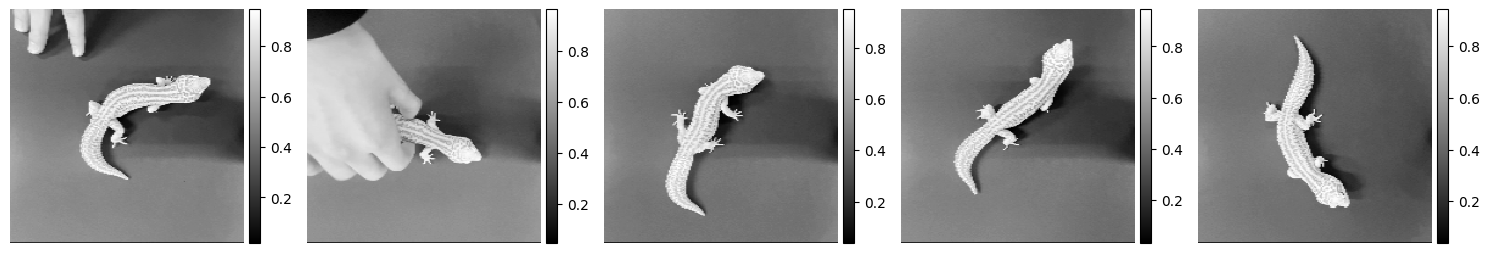

In [112]:
# re-visualize
example_digits = [f for f in x_train[idx, ...]]
ne.plot.slices(example_digits, cmaps=['gray'], do_colorbars=True);

In [113]:


# verify
print('shape of training data', x_train.shape)

shape of training data (6447, 192, 192)


In [114]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 2
unet_input_features = 2
inshape = (*x_train.shape[1:], unet_input_features)

# configure unet features 
nb_features = [
    [32, 32, 32, 32],         # encoder features
    [32, 32, 32, 32, 32, 16]  # decoder features
]

# build model
unet = vxm.networks.Unet(inshape=inshape, nb_features=nb_features)

In [115]:
# transform the results into a flow field.
disp_tensor = tf.keras.layers.Conv2D(ndim, kernel_size=3, padding='same', name='disp')(unet.output)

# check tensor shape
print('displacement tensor:', disp_tensor.shape)

# using keras, we can easily form new models via tensor pointers
def_model = tf.keras.models.Model(unet.inputs, disp_tensor)

displacement tensor: (None, 192, 192, 2)


In [116]:
# build transformer layer
spatial_transformer = vxm.layers.SpatialTransformer(name='transformer')

# extract the first frame (i.e. the "moving" image) from unet input tensor
moving_image = tf.expand_dims(unet.input[..., 0], axis=-1)

# warp the moving image with the transformer
moved_image_tensor = spatial_transformer([moving_image, disp_tensor])

In [117]:
outputs = [moved_image_tensor, disp_tensor]
vxm_model = tf.keras.models.Model(inputs=unet.inputs, outputs=outputs)

In [118]:
# build model using VxmDense
inshape = x_train.shape[1:]
vxm_model = vxm.networks.VxmDense(inshape, nb_features, int_steps=0)

In [119]:
# voxelmorph has a variety of custom loss classes
losses = [vxm.losses.MSE().loss, vxm.losses.Grad('l2').loss]

# usually, we have to balance the two losses by a hyper-parameter
lambda_param = 0.05
loss_weights = [1, lambda_param]

In [120]:
vxm_model.compile(optimizer='Adam', loss=losses, loss_weights=loss_weights)

In [121]:
print(x_data.shape)

(8447, 192, 192)


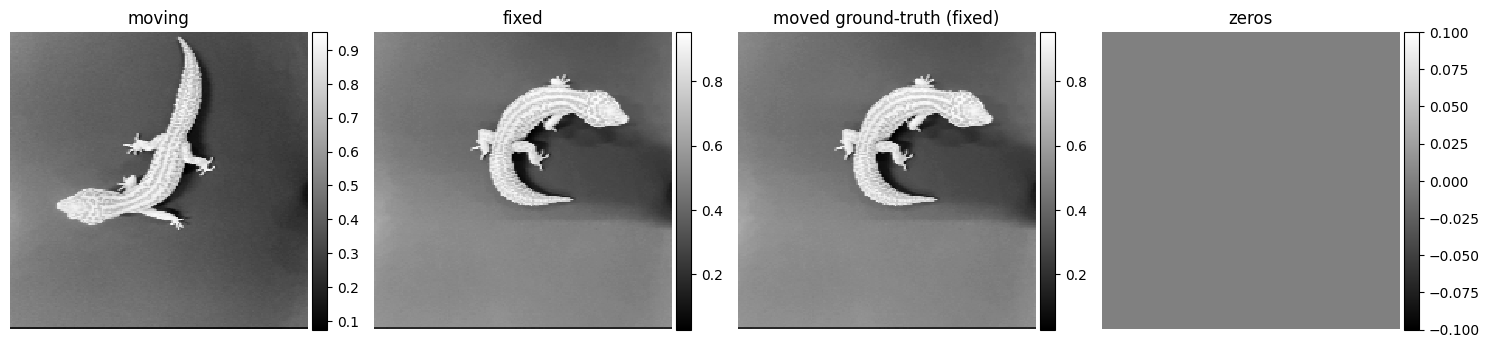

In [130]:
# let's test it
train_generator = vxm_data_generator(x_train)
in_sample, out_sample = next(train_generator)

# visualize
images = [img[0, :, :, 0] for img in in_sample + out_sample] 
titles = ['moving', 'fixed', 'moved ground-truth (fixed)', 'zeros']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

In [123]:
nb_epochs = 200
steps_per_epoch = 100
hist = vxm_model.fit_generator(train_generator, epochs=nb_epochs, steps_per_epoch=steps_per_epoch, verbose=2);

Epoch 1/200


C:\Users\orilab\AppData\Local\Temp\ipykernel_47432\2476017339.py:3: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  hist = vxm_model.fit_generator(train_generator, epochs=nb_epochs, steps_per_epoch=steps_per_epoch, verbose=2);


100/100 - 152s - loss: 0.0229 - vxm_dense_transformer_loss: 0.0216 - vxm_dense_flow_loss: 0.0264 - 152s/epoch - 2s/step
Epoch 2/200
100/100 - 165s - loss: 0.0189 - vxm_dense_transformer_loss: 0.0164 - vxm_dense_flow_loss: 0.0510 - 165s/epoch - 2s/step
Epoch 3/200
100/100 - 170s - loss: 0.0180 - vxm_dense_transformer_loss: 0.0151 - vxm_dense_flow_loss: 0.0572 - 170s/epoch - 2s/step
Epoch 4/200
100/100 - 170s - loss: 0.0175 - vxm_dense_transformer_loss: 0.0144 - vxm_dense_flow_loss: 0.0610 - 170s/epoch - 2s/step
Epoch 5/200
100/100 - 162s - loss: 0.0165 - vxm_dense_transformer_loss: 0.0134 - vxm_dense_flow_loss: 0.0623 - 162s/epoch - 2s/step
Epoch 6/200
100/100 - 151s - loss: 0.0169 - vxm_dense_transformer_loss: 0.0136 - vxm_dense_flow_loss: 0.0661 - 151s/epoch - 2s/step
Epoch 7/200
100/100 - 151s - loss: 0.0166 - vxm_dense_transformer_loss: 0.0133 - vxm_dense_flow_loss: 0.0672 - 151s/epoch - 2s/step
Epoch 8/200
100/100 - 151s - loss: 0.0164 - vxm_dense_transformer_loss: 0.0129 - vxm_den

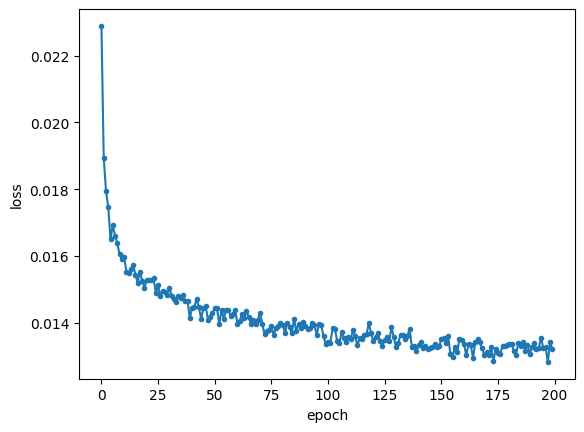

In [124]:
import matplotlib.pyplot as plt

def plot_history(hist, loss_name='loss'):
    # Simple function to plot training history.
    plt.figure()
    plt.plot(hist.epoch, hist.history[loss_name], '.-')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

plot_history(hist)

In [125]:
# let's get some data
val_generator = vxm_data_generator(x_val, batch_size = 1)
val_input, _ = next(val_generator)

In [126]:
val_pred = vxm_model.predict(val_input)

1/1 [==============================] - 0s 144ms/step


In [127]:
# %timeit is a 'jupyter magic' that times the given line over several runs
%timeit vxm_model.predict(val_input)

1/1 [==============================] - 0s 24ms/step
40.3 ms ± 626 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


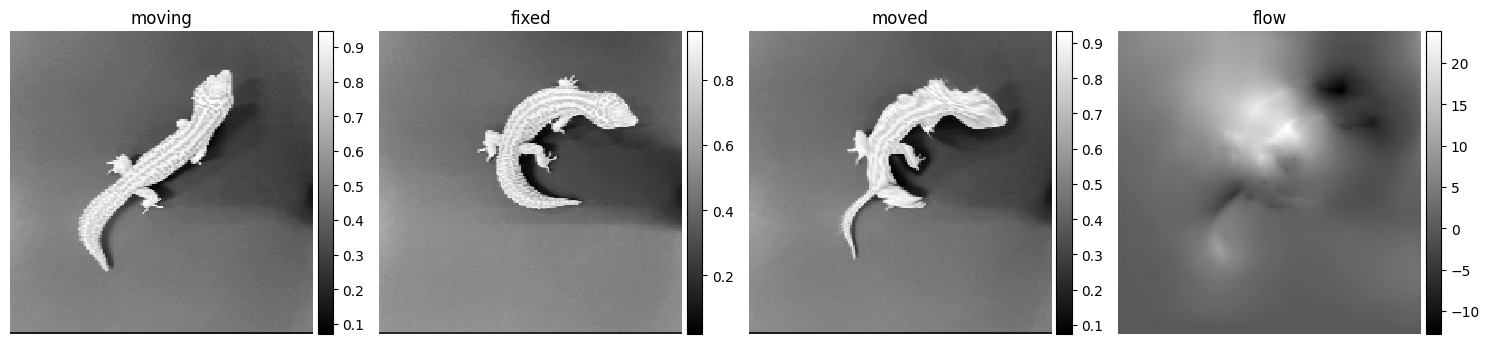

In [128]:
# visualize
images = [img[0, :, :, 0] for img in val_input + val_pred] 
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True);

1/1 [==============================] - 0s 12ms/step


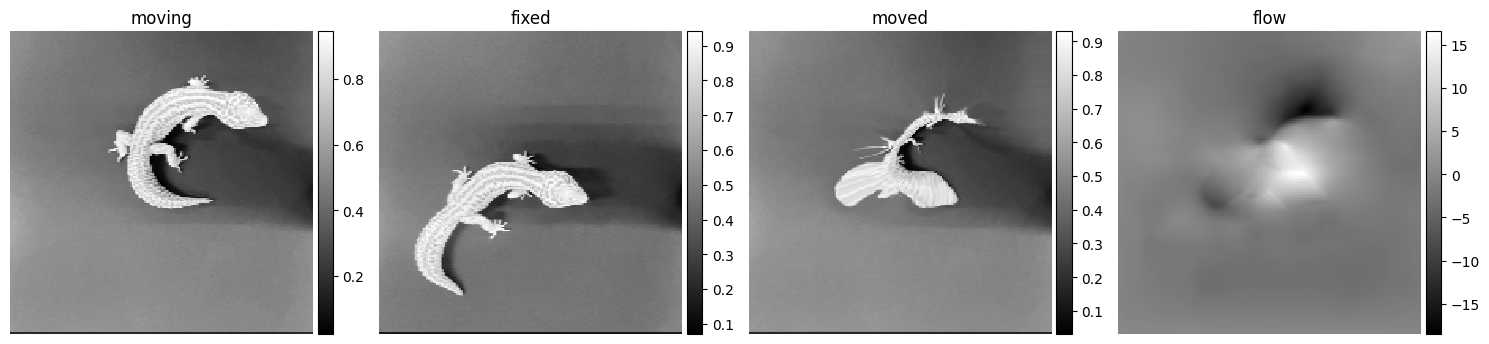

(<Figure size 1500x375 with 8 Axes>,
 array([<Axes: title={'center': 'moving'}>,
        <Axes: title={'center': 'fixed'}>,
        <Axes: title={'center': 'moved'}>,
        <Axes: title={'center': 'flow'}>], dtype=object))

In [137]:
import random

# バッチサイズ1のgeneratorから1件取得（val_input, val_predの中身も更新されている想定）
val_sample = next(val_generator)
val_input = val_sample[0]
val_pred = vxm_model.predict(val_input)

# ランダムなindexを取得（バッチサイズ=1なら常に0でもOKだけど、将来の拡張を考えて）
idx = random.randint(0, val_input[0].shape[0] - 1)

# 可視化（バッチサイズ1なら常にidx=0でよい）
images = [
    val_input[0][idx, :, :, 0],  # moving
    val_input[1][idx, :, :, 0],  # fixed
    val_pred[0][idx, :, :, 0],   # moved
    val_pred[1][idx, :, :, 0]    # flow
]
titles = ['moving', 'fixed', 'moved', 'flow']
ne.plot.slices(images, titles=titles, cmaps=['gray'], do_colorbars=True)
